In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("nrl_weather_analysis_data.csv")

In [2]:
df["rain_bucket"] = pd.cut(df["match_window_rain_mm"],
                           bins=[-0.01, 0, 1 ,5, 100],
                           labels=["dry", "light", "moderate", "heavy"])
df.groupby("rain_bucket", observed=True)["total_tries"].agg(["mean", "count", "std"])

,mean,count,std
rain_bucket,,,
dry,7.857588,1285,2.535563
light,7.257778,225,2.441319
moderate,7.371429,70,1.986705
heavy,6.315789,19,2.539743


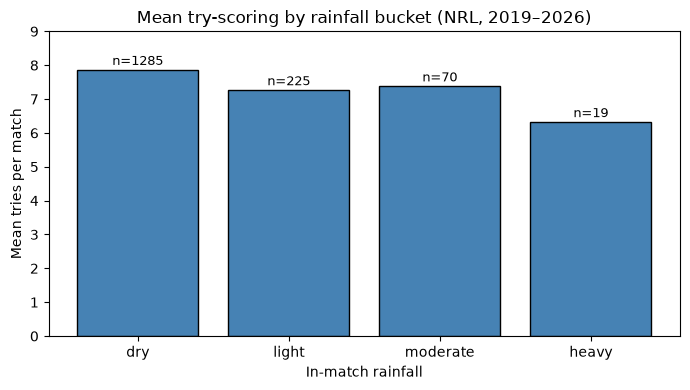

In [3]:
import matplotlib.pyplot as plt

bucket_means = df.groupby("rain_bucket", observed=True)["total_tries"].mean()
bucket_counts = df.groupby("rain_bucket", observed=True)["total_tries"].count()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(bucket_means.index, bucket_means.values, color="steelblue", edgecolor="black")
ax.set_ylabel("Mean tries per match")
ax.set_xlabel("In-match rainfall")
ax.set_title("Mean try-scoring by rainfall bucket (NRL, 2019–2026)")
ax.set_ylim(0, 9)

# annotate each bar with its sample size — the honesty built into the chart
for i, (mean, n) in enumerate(zip(bucket_means.values, bucket_counts.values)):
    ax.text(i, mean + 0.15, f"n={n}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## Does rain affect try-scoring?

The buckets group matches by in-match rainfall. Try-scoring is the highest in dry games (7.9) and lowest in games with heavy rain (6.3), albeit with a modest sample size. However, the directional effect is supported by both the light and moderate buckets. 

## Dry versus wet games

Given more than 75% of matches are completely dry, the bucket analysis of wet weather NRL is thin. Therefore, a decision was made to collapse the analysis to dry games versus wet games. 

We use 1mm as the threshold, the point where rainfall appears to have a material impact on ball-handling and the surface. 

In [4]:
threshold = 1
df["is_wet"] = df["match_window_rain_mm"] >= threshold
df.groupby("is_wet", observed=True)["total_tries"].agg(["mean", "count", "std"])

for t in [0.5, 1.0, 2.0]:
    wet = df["match_window_rain_mm"] >= t
    means = df.groupby(wet, observed=True)["total_tries"].mean()
    gap = means[False] - means[True]
    n_wet = wet.sum()
    print(f"threshold {t}mm: dry {means[False]:.2f} vs wet {means[True]:.2f}  |  gap {gap:.2f}  |  wet n={n_wet}")

threshold 0.5mm: dry 7.81 vs wet 7.09  |  gap 0.71  |  wet n=163
threshold 1.0mm: dry 7.77 vs wet 7.20  |  gap 0.57  |  wet n=97
threshold 2.0mm: dry 7.76 vs wet 6.96  |  gap 0.80  |  wet n=57


## Findings

Splitting games into dry vs wet (>0.99mm), shows wet games score approx. 
0.6-0.8 fewer tries. The trend is directionally clear, and now we will ascertain it's significance. 

In [5]:
from scipy import stats

dry_tries = df[df["match_window_rain_mm"] < 1.0]["total_tries"]
wet_tries = df[df["match_window_rain_mm"] >= 1.0]["total_tries"]

print("dry:", len(dry_tries), "games, mean", round(dry_tries.mean(), 2))
print("wet:", len(wet_tries), "games, mean", round(wet_tries.mean(), 2))

t_stat, p_value = stats.ttest_ind(dry_tries, wet_tries, equal_var=False)
print("t-statistic:", round(t_stat, 3))
print("p-value:", round(p_value, 4))

dry: 1502 games, mean 7.77
wet: 97 games, mean 7.2
t-statistic: 2.498
p-value: 0.0139


## Final Rain Findings

A t-test on dry versus wet games returns t = 2.5, p = 0.014. With p firmly under the threshold of significance, the difference is statistically significant. 

That said, the effect is modest. Finding that in wet games, approx. 0.6 fewer tries are scored which is smaller than game-to-game variation 
(std = 2.5).

Now we will analyse the impact of wind, using a different approach given the shape of the readings are different to the zero-inflated rain readings.

In [6]:
df["match_window_mean_wind_speed_kph"].describe()

count    1599.000000
mean       10.837419
std         5.482424
min         1.800000
25%         6.933333
50%         9.450000
75%        13.658333
max        39.433333
Name: match_window_mean_wind_speed_kph, dtype: float64

## Wind Regression

Given the shape of the data, we will head straight to a linear regression test to ascertain the impact of wind on try-scoring. 

In [7]:
import statsmodels.formula.api as smf

model = smf.ols("total_tries ~ match_window_mean_wind_speed_kph", data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            total_tries   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     5.982
Date:                Sun, 30 Aug 2026   Prob (F-statistic):             0.0146
Time:                        18:11:20   Log-Likelihood:                -3739.2
No. Observations:                1599   AIC:                             7482.
Df Residuals:                    1597   BIC:                             7493.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

## Wind Findings

Contrary to our initial hypothesis, wind actually has a statistically significant, positive association with scoring. With an additional 1kph of wind resulting in an additional 0.028 tries.

However, with only 0.4% in try variation being attributed to wind, it is essentially a rounding error when it comes to predicting the amount of tries in a match.  

Now, we will look at the combinatory effects of wind and rain. Running a poisson regression with wind (kph) and rain (mm) as continuos variables, with the independent variable; tries scored.

In [8]:
import statsmodels.formula.api as smf

poisson_model = smf.poisson(
    "total_tries ~ match_window_rain_mm + match_window_mean_wind_speed_kph",
    data=df
).fit()
print(poisson_model.summary())

Optimization terminated successfully.
         Current function value: 2.348944
         Iterations 4
                          Poisson Regression Results                          
Dep. Variable:            total_tries   No. Observations:                 1599
Model:                        Poisson   Df Residuals:                     1596
Method:                           MLE   Df Model:                            2
Date:                Sun, 30 Aug 2026   Pseudo R-squ.:                0.001641
Time:                        18:11:20   Log-Likelihood:                -3756.0
converged:                       True   LL-Null:                       -3762.1
Covariance Type:            nonrobust   LLR p-value:                  0.002080
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                            2.0065      0.020    100.82

## Final Findings

A Poisson Regression was chosen due to the non-negative nature of try counts and the fact that their variance scales with their mean, OLS would assume constant variance and predict impossible negative values. 

The findings are clear, rain survives as a significant variable with a negative relationship towards try-scoring. Wind also hold's its positive relationship with scoring (controlling for rain) at a negligible +0.0041 tries per 1kph of wind added.

The  directionality of rain's association with scoring is clear. However, with a Pseudo R-Squared of 0.16%, weather forecasts would not be tremendously useful in predicting the amount of tries scored in an NRL match. 

## Limitations & Conclusion

Given the sample size of games with heavy rain, it would be hard to statistically assert that those games definitively reduce try-scoring by approx 1.4 tries, due to the 19 game sample. Moreover, with only 97 games exhibiting > 1mm of rain during the match, these imprescise estimates would not generalise well with a fitted model. 

In contrast, rain shows a clear negative relationship with try-scoring, while wind's effect is negligible. The statistical significance of rain 
(p = 0.008 in the poisson regression) is consistent with the idea that a rainy NRL game tends to be lower-scoring than a dry one. 
